# Group Project
Course: MIS 443 -
Principles of Data Analytics

Quarter 4/2025-2026

Lecturer: 	Đặng Thế Đoàn

Group:  DataMinds

TEAM MEMBERS

Nguyễn Thị Ánh Tuyết  2332300334

Phạm Thùy Trang 2332300158

Tăng Sở Hân 2332300046

Lữ Anh Thư 2332300138





##**1. Introduction**

This project analyzes the DataCo Supply Chain dataset using PostgreSQL and Python to evaluate business performance and supply chain operations.

The project consists of two main stages:

- **PostgreSQL:** Data import, normalization, relational database design, and SQL-based business analysis.
- **Python:** Data cleaning, Exploratory Data Analysis (EDA), data visualization, and business insights.

The original dataset was normalized into six relational tables (Customers, Orders, OrderItems, Products, Categories, and Departments) to improve data integrity, reduce redundancy, and support efficient data management. The integrated analytical dataset was then exported to Python for further analysis.

This project focuses on analyzing business performance from multiple perspectives, including business overview, product performance, customer behavior, logistics performance, time trends, and relationships among key numerical variables. The findings provide valuable insights to support data-driven business decision-making.

##**2. Import Libraries**

This section imports the Python libraries required for data manipulation, visualization, and statistical analysis throughout the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import numpy as np
from sqlalchemy import create_engine

##**3. Load Dataset**

The analytical dataset exported from PostgreSQL is loaded into Python for data cleaning, exploratory data analysis (EDA), and visualization.

In [2]:
df = pd.read_csv(
    "/content/dataset.csv",
    engine="python"
)

##**4. Dataset Overview**

###4.1 Dataset Preview

In [3]:
df.head(5)

,order_item_id,order_id,order_date,shipping_date,customer_id,first_name,last_name,segment,city,state,...,sales,item_total,profit,discount,discount_rate,shipping_real_days,shipping_scheduled_days,shipping_mode,delivery_status,order_status
0,1,1,2015-01-01 00:00:00,2015-01-03 00:00:00,11599,Mary,Malone,Consumer,Hickory,NC,...,299.98,239.98,88.79,60.0,0.20,2,4,Standard Class,Advance shipping,CLOSED
1,2,2,2015-01-01 00:21:00,2015-01-04 00:21:00,256,David,Rodriguez,Consumer,Chicago,IL,...,199.99,193.99,91.18,6.0,0.03,3,4,Standard Class,Advance shipping,PENDING_PAYMENT
2,3,2,2015-01-01 00:21:00,2015-01-04 00:21:00,256,David,Rodriguez,Consumer,Chicago,IL,...,250.00,227.50,68.25,22.5,0.09,3,4,Standard Class,Advance shipping,PENDING_PAYMENT
3,4,2,2015-01-01 00:21:00,2015-01-04 00:21:00,256,David,Rodriguez,Consumer,Chicago,IL,...,129.99,107.89,36.47,22.1,0.17,3,4,Standard Class,Advance shipping,PENDING_PAYMENT
4,5,4,2015-01-01 01:03:00,2015-01-06 01:03:00,8827,Brian,Wilson,Home Office,San Antonio,TX,...,49.98,40.98,4.10,9.0,0.18,5,4,Standard Class,Late delivery,CLOSED


In [4]:
df.shape

(180519, 26)

The dataset contains 180,519 records and 26 columns, including both numerical and categorical variables.

###4.2 Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_item_id            180519 non-null  int64  
 1   order_id                 180519 non-null  int64  
 2   order_date               180519 non-null  object 
 3   shipping_date            180519 non-null  object 
 4   customer_id              180519 non-null  int64  
 5   first_name               180519 non-null  object 
 6   last_name                180511 non-null  object 
 7   segment                  180519 non-null  object 
 8   city                     180519 non-null  object 
 9   state                    180519 non-null  object 
 10  country                  180519 non-null  object 
 11  department_name          180519 non-null  object 
 12  category_name            180519 non-null  object 
 13  product_name             180519 non-null  object 
 14  prod


 Most columns are complete, with only **8 missing values** in the `last_name` column, while `order_date` and `shipping_date` will be converted to the `datetime` format during data cleaning.

###4.3 Summary Statistics

In [6]:
df.describe()

,order_item_id,order_id,customer_id,product_price,quantity,sales,item_total,profit,discount,discount_rate,shipping_real_days,shipping_scheduled_days
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,90260.000000,36221.894903,6691.379495,141.232547,2.127638,203.772092,183.107607,21.974989,20.664741,0.101668,3.497654,2.931847
std,52111.490959,21045.379569,4162.918106,139.732489,1.453451,132.273075,120.043668,104.433526,21.800901,0.070415,1.623722,1.374449
min,1.000000,1.000000,1.000000,9.990000,1.000000,9.990000,7.490000,-4274.980000,0.000000,0.000000,0.000000,0.000000
25%,45130.500000,18057.000000,3258.500000,50.000000,1.000000,119.980000,104.380000,7.000000,5.400000,0.040000,2.000000,2.000000
50%,90260.000000,36140.000000,6457.000000,59.990000,1.000000,199.920000,163.990000,31.520000,14.000000,0.100000,3.000000,4.000000
75%,135389.500000,54144.000000,9779.000000,199.990000,3.000000,299.950000,247.400000,64.800000,29.990000,0.160000,5.000000,4.000000
max,180519.000000,77204.000000,20757.000000,1999.990000,5.000000,1999.990000,1939.990000,911.800000,500.000000,0.250000,6.000000,4.000000




The summary statistics show considerable variation in sales, profit, and quantity across transactions. Notably, the minimum profit is negative, indicating that some transactions resulted in a financial loss.

##**5. Data Cleaning**

###5.1 Missing Value Analysis

Checking whether the dataset contains missing values before performing analysis.


In [7]:
df.isnull().sum()

,0
order_item_id,0
order_id,0
order_date,0
shipping_date,0
customer_id,0
first_name,0
last_name,8
segment,0
city,0
state,0


In [8]:
df["last_name"] = df["last_name"].fillna("Unknown")

In [9]:
df.isnull().sum()

,0
order_item_id,0
order_id,0
order_date,0
shipping_date,0
customer_id,0
first_name,0
last_name,0
segment,0
city,0
state,0


Missing values were found only in a few categorical variables.

These values were replaced with "Unknown" rather than removed to maintain consistency with the PostgreSQL database.


###5.2 Duplicate Check

Check whether duplicate observations exist in the exported dataset.

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


###5.3 Date Conversion

Convert date columns into datetime format for time-series analysis.

In [11]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["shipping_date"] = pd.to_datetime(df["shipping_date"])

In [12]:
df.dtypes

,0
order_item_id,int64
order_id,int64
order_date,datetime64[ns]
shipping_date,datetime64[ns]
customer_id,int64
first_name,object
last_name,object
segment,object
city,object
state,object


##**Data Preparation Insight**
After data cleaning, the dataset is complete, consistent, and ready for exploratory data analysis. Missing values have been addressed, duplicate records were not found, and the date variables have been converted to the appropriate format.

##**6. Business Overview**

###6.1 Business KPI Overview

This section presents the key performance indicators (KPIs) that summarize the overall business performance.

The KPIs include:

- Total Sales
- Total Profit
- Average Order Value (AOV)

These metrics provide a high-level understanding of the business before performing detailed exploratory data analysis.

In [13]:
total_sales = df["sales"].sum()

total_profit = df["profit"].sum()

average_order = df["item_total"].mean()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Order Value: ${average_order:,.2f}")

Total Sales: $36,784,734.31
Total Profit: $3,966,902.97
Average Order Value: $183.11


##**7. Product Performance**

###7.1 Top 10 Best-selling Products

The chart shows the ten products with the highest quantity sold. These products consistently achieve the highest sales volume, indicating strong customer demand.

Top 10 Best-selling Products Data:
product_name
Perfect Fitness Perfect Rip Deck                 73698
Nike Men's Dri-FIT Victory Golf Polo             62956
O'Brien Men's Neoprene Life Vest                 57803
Nike Men's Free 5.0+ Running Shoe                36680
Under Armour Girls' Toddler Spine Surge Runni    31735
Nike Men's CJ Elite 2 TD Football Cleat          22246
Field & Stream Sportsman 16 Gun Fire Safe        17325
Pelican Sunstream 100 Kayak                      15500
Diamondback Women's Serene Classic Comfort Bi    13729
ENO Atlas Hammock Straps                           998
Name: quantity, dtype: int64


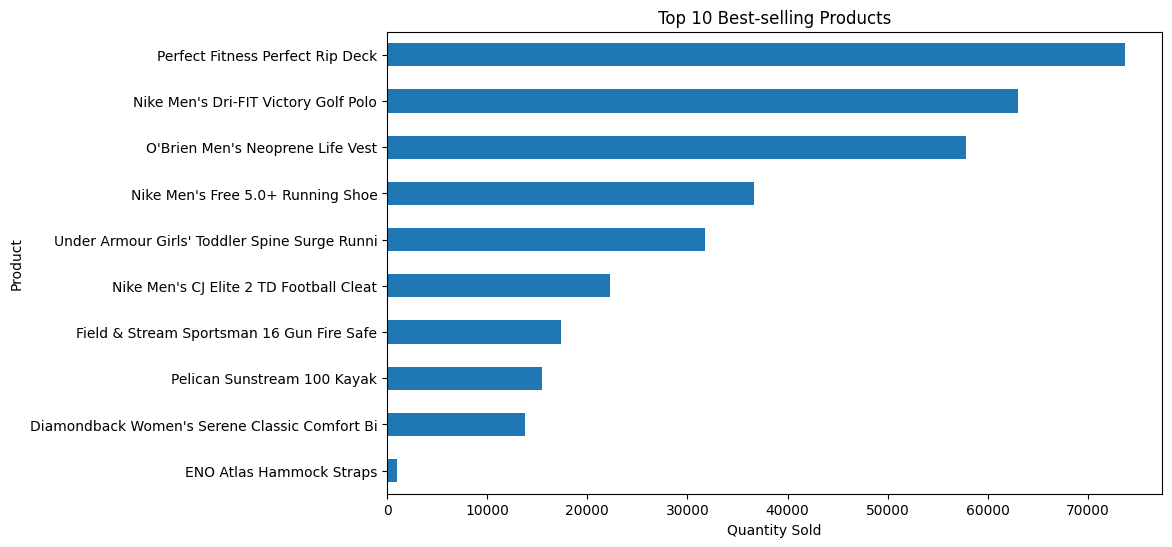

In [14]:
top_products = (
    df.groupby("product_name")["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Best-selling Products Data:")
print(top_products)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

The best-selling products should be prioritized for inventory management and stock replenishment to prevent stock shortages and maintain sales performance.

###7.2 Bottom 10 Least-selling Products

The least-selling products have very low sales volume compared with the best-selling products, indicating limited customer demand.

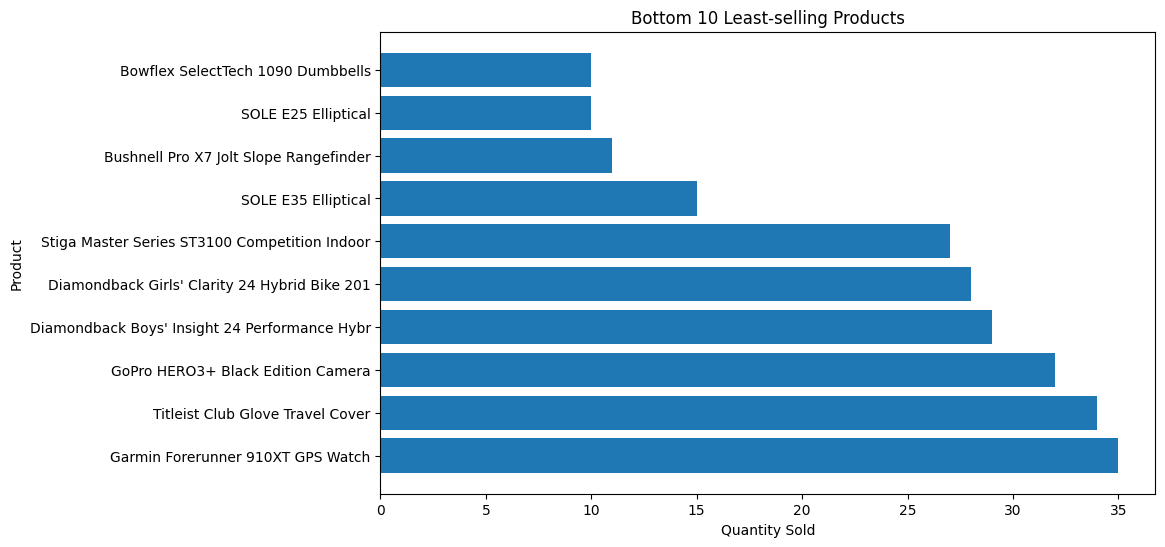

In [15]:
least_products = (
    df.groupby("product_name")["quantity"]
      .sum()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(least_products.index[::-1], least_products.values[::-1])

plt.title("Bottom 10 Least-selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

The least-selling products should be reviewed to determine whether improvements in pricing, promotion, or inventory management are needed to enhance their performance.

### 7.3 Revenue by Product Category

This chart compares total sales generated by each product category.

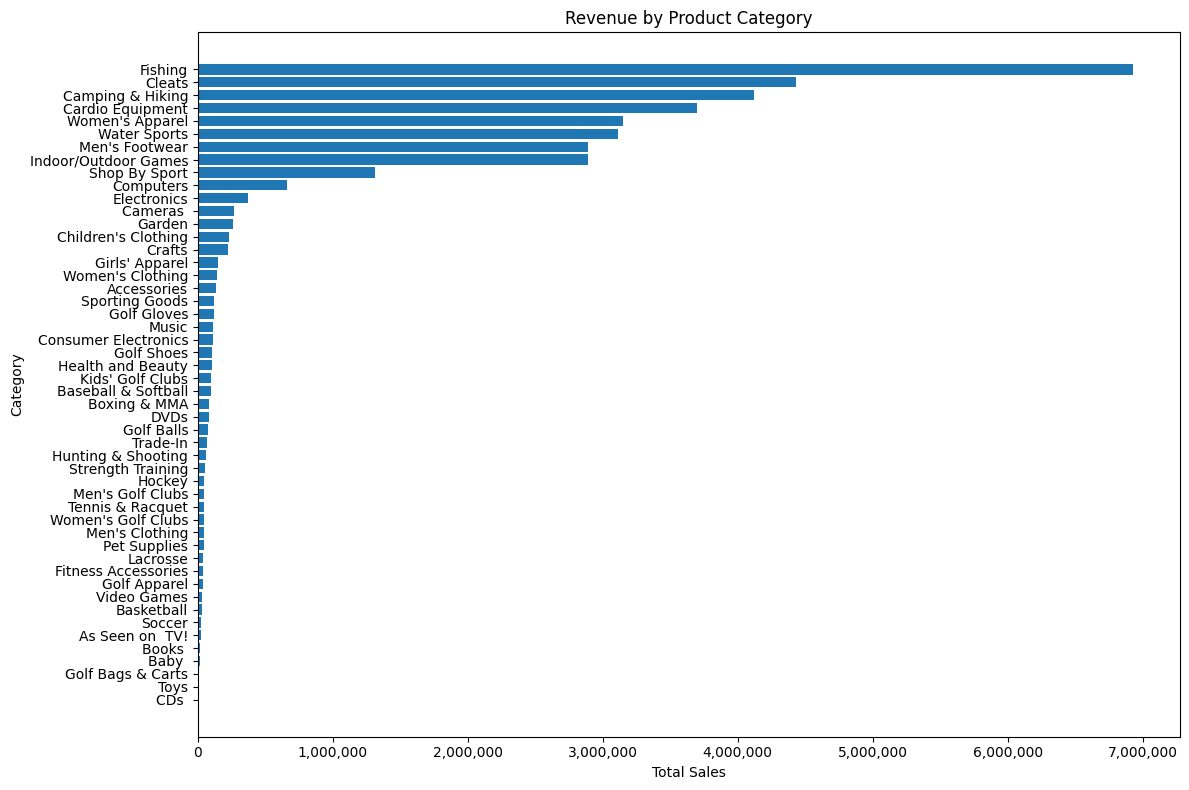

In [16]:
from matplotlib.ticker import StrMethodFormatter

category_sales = (
    df.groupby("category_name")["sales"]
      .sum()
      .sort_values()
)

fig, ax = plt.subplots(figsize=(12,8))

ax.barh(category_sales.index, category_sales.values)

ax.set_title("Revenue by Product Category")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Category")

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

High-revenue categories should remain a priority for inventory planning and marketing activities, while lower-performing categories may require further evaluation to improve sales.

### 7.4 Revenue by Department

This chart compares total sales across business departments.

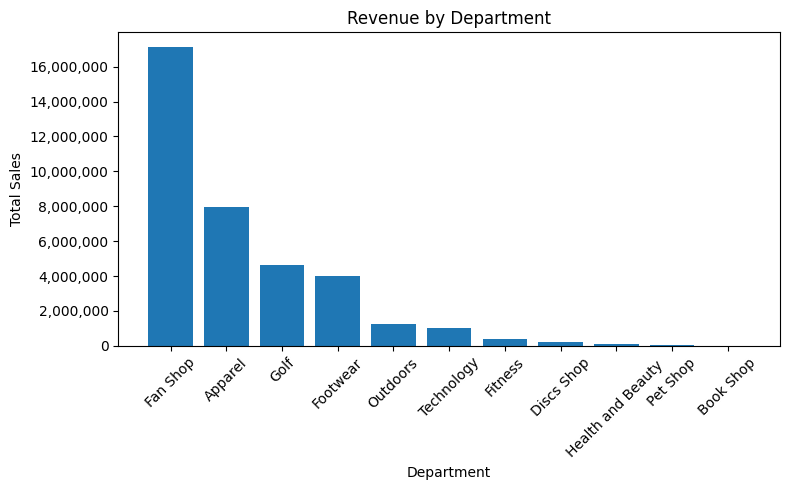

In [17]:
department_sales = (
    df.groupby("department_name")["sales"]
      .sum()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(department_sales.index, department_sales.values)

ax.set_title("Revenue by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Total Sales")

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The highest-revenue department should such as **Fan Shop**, **Apparel** should remain a strategic priority for resource allocation and operational support, while other departments can be evaluated for growth opportunities and performance improvement.

## **8. Customer Analysic**

### 8.1 Sales by Customer Segment

This chart compares total sales generated by different customer segments.

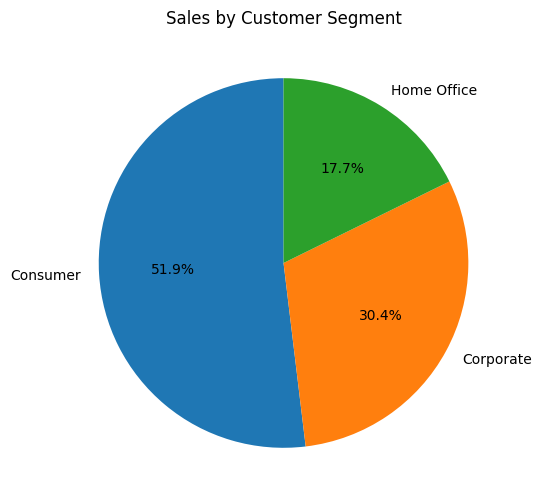

In [18]:
segment_sales = (
    df.groupby("segment")["sales"]
      .sum()
)

plt.figure(figsize=(6,6))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales by Customer Segment")

plt.show()



Customer segments contribute differently to total sales. The highest-performing segment represents the company's primary source of revenue and should remain the focus of customer retention and marketing strategies.

### 8.2 Top 10 States by Sales

This chart identifies the states generating the highest total sales revenue.

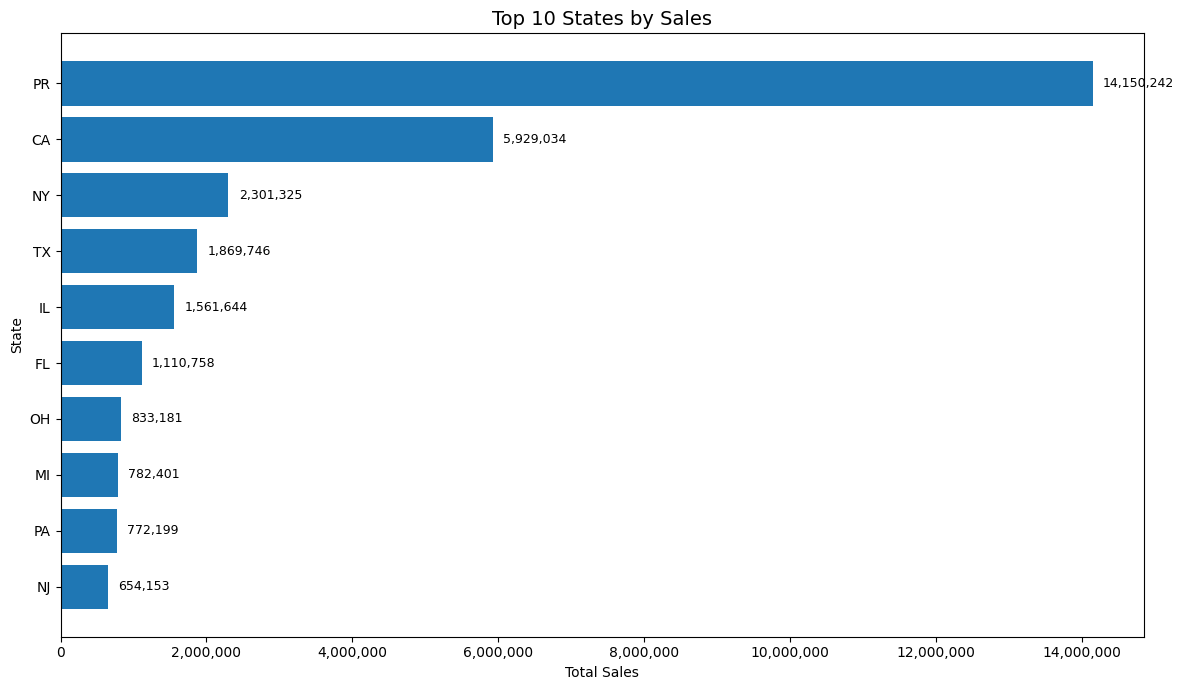

In [19]:
top_states = (
    df.groupby("state")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_states = (
    df.groupby("state")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(12,7))

bars = ax.barh(top_states.index[::-1], top_states.values[::-1])

ax.set_title("Top 10 States by Sales", fontsize=14)
ax.set_xlabel("Total Sales")
ax.set_ylabel("State")

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

for bar in bars:
    ax.text(
        bar.get_width() + max(top_states.values) * 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.0f}',
        va='center',
        fontsize=9
    )

plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

High-performing states represent the company's strongest markets. These regions should remain a priority for inventory planning, marketing activities, and customer relationship management.

##**9. Logistic Analysic**

###9.1  Shipping Mode Distribution

This chart illustrates the number of orders delivered using each shipping method.

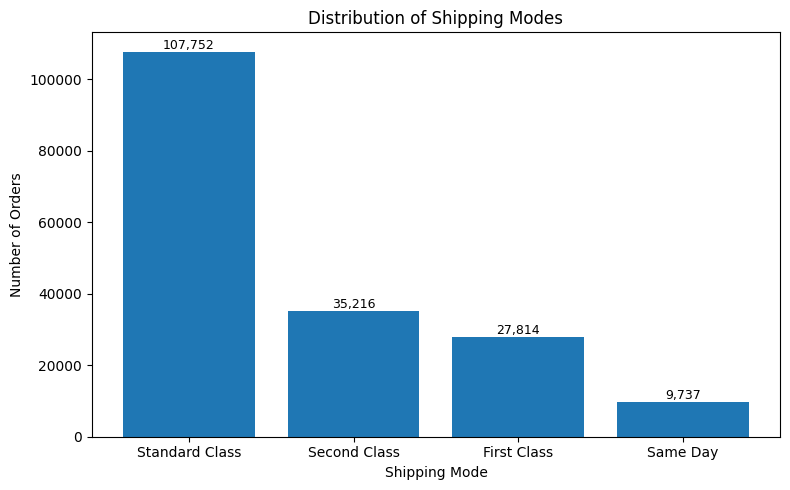

In [20]:
shipping_mode = df["shipping_mode"].value_counts()

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(shipping_mode.index, shipping_mode.values)

ax.set_title("Distribution of Shipping Modes")
ax.set_xlabel("Shipping Mode")
ax.set_ylabel("Number of Orders")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()



Standard Class is expected to be the most frequently used shipping method due to its lower operational cost. The distribution helps evaluate customer preferences and optimize logistics planning.

### 9.2 Delivery Status Distribution

This chart presents the proportion of orders by delivery status.

In [21]:
delivery = df["delivery_status"].value_counts()
delivery

,count
delivery_status,
Late delivery,98977
Advance shipping,41592
Shipping on time,32196
Shipping canceled,7754


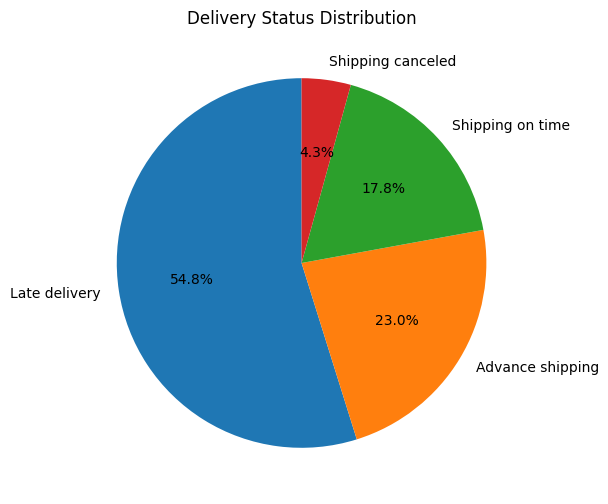

In [22]:
plt.figure(figsize=(6,6))

plt.pie(
    delivery,
    labels=delivery.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Delivery Status Distribution")

plt.show()

Late Delivery accounts for more than half of all orders, suggesting that delivery timeliness is a key operational challenge. Improving delivery scheduling and logistics efficiency could help reduce delays and enhance customer satisfaction.

###9.3 On-time vs Delayed Deliveries

Orders are classified as **On Time** when the actual shipping days are less than or equal to the scheduled shipping days.

Otherwise, the order is classified as **Delayed**.

In [23]:
df["delivery_performance"] = np.where(
    df["shipping_real_days"] <= df["shipping_scheduled_days"],
    "On Time",
    "Delayed"
)

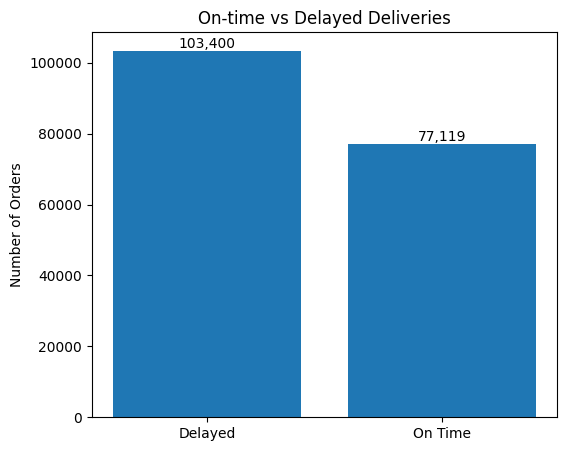

In [24]:
performance = df["delivery_performance"].value_counts()

fig, ax = plt.subplots(figsize=(6,5))

bars = ax.bar(performance.index, performance.values)

ax.set_title("On-time vs Delayed Deliveries")
ax.set_ylabel("Number of Orders")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom'
    )

plt.show()



The proportion of on-time deliveries reflects the company's logistics efficiency.

A high percentage of delayed deliveries may indicate issues in transportation planning, warehouse operations, or supply chain coordination.

##**10. Time Analysic**

###10.1  Monthly Sales Trend

This chart illustrates the total monthly sales revenue based on the order date.

Analyzing monthly sales trends helps identify peak sales periods and seasonal demand patterns.

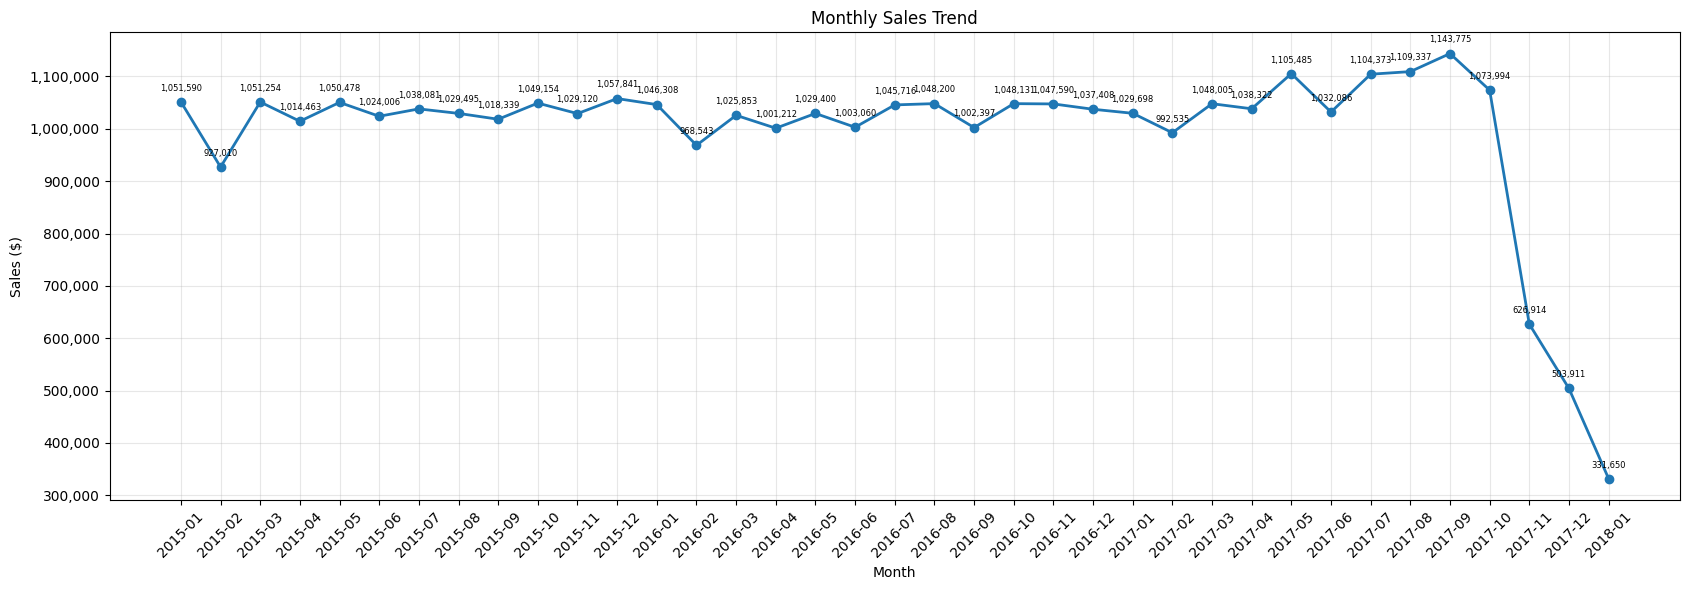

In [27]:
from matplotlib.ticker import FuncFormatter
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create Year-Month column
df['YearMonth'] = df['order_date'].dt.to_period('M').astype(str)

# Monthly Sales
monthly_sales = (
    df.groupby('YearMonth')['sales']
      .sum()
      .reset_index()
)

# Plot
plt.figure(figsize=(17,6))

plt.plot(
    monthly_sales['YearMonth'],
    monthly_sales['sales'],
    marker='o',
    linewidth=2
)

# Display values
for x, y in zip(monthly_sales['YearMonth'], monthly_sales['sales']):
    plt.annotate(
        f'{y:,.0f}',
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha='center',
        fontsize=6
    )

# Format Y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Sales remained relatively stable at around 1.0-1.1M dollar per month for most of the period, peaked at 1.14M dollar in 2017-08, then declined sharply from 2017-10 to 331.65K dollar in 2018-01.

###10.2 Profit Sales Trend

This chart illustrates the total monthly revenue based on the order date.

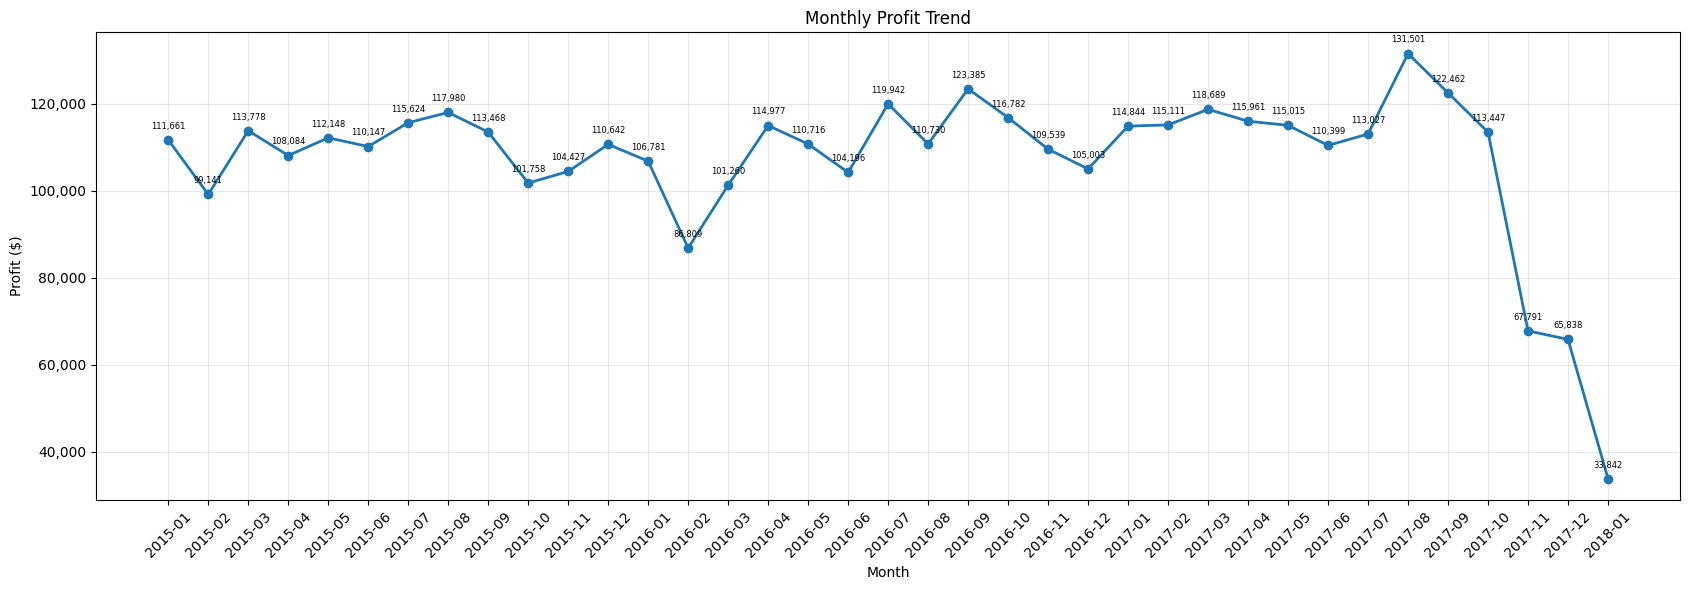

In [28]:
# Monthly Profit
monthly_profit = (
    df.groupby('YearMonth')['profit']
      .sum()
      .reset_index()
)

# Plot
plt.figure(figsize=(17,6))

plt.plot(
    monthly_profit['YearMonth'],
    monthly_profit['profit'],
    marker='o',
    linewidth=2
)

# Display values
for x, y in zip(monthly_profit['YearMonth'], monthly_profit['profit']):
    plt.annotate(
        f'{y:,.0f}',
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha='center',
        fontsize=6
    )

# Format Y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Profit generally stayed around 100K–120K dollar per month, reaching a peak of 131.5K dollar in 2017-07, before falling sharply to 33.84K dolar in 2018-01.

## **Exploratory Data Analysis Summary**



The exploratory data analysis identified several key findings regarding DataCo's sales performance, customer behavior, product performance, logistics operations, and business trends.

- Product performance was highly concentrated. A small number of products and product categories generated the majority of sales revenue, while several products contributed only a limited share of total sales. This suggests that revenue is driven primarily by a few high-performing products.

- Customer analysis showed that the **Consumer** segment generated the largest proportion of total sales. Sales distribution also varied across states, indicating that customer demand is stronger in specific geographic markets.

- Logistics analysis revealed that **Late Delivery** represented the largest share of shipping outcomes, suggesting that delivery delays remain a significant operational issue. Improving shipping efficiency could enhance customer satisfaction and overall business performance.

- Sales and profit show a similar overall pattern, suggesting that changes in sales are generally accompanied by changes in profit. Both metrics reached their highest levels in mid-2017 before declining sharply toward the end of the period.

Overall, the analysis highlights that business performance is driven by high-performing products, key customer segments, and major regional markets. At the same time, optimizing delivery performance and discount strategies could further improve operational efficiency and profitability.

## **Conclusion**

By integrating PostgreSQL and Python, this project successfully analyzed DataCo's sales, customers, products, logistics, and business trends. The results provide meaningful insights into business performance and highlight opportunities to improve delivery efficiency, pricing strategies, and overall profitability. Overall, the analysis demonstrates how data-driven decision-making can support better business planning and operational performance.